# 1. Importar librerias necesarias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# 2. Cargar y revisar el archivo a evaluar

In [2]:
df = pd.read_excel("C:\\Users\\kevin\\OneDrive\\Escritorio\\VISUAL ARCHIVOS\\VENTAS ABRIL 19.xls")

In [3]:
df

,C.O.,Nro documento,Fecha,Estado,Razón social cliente factura,Bodega,Item,Referencia,Desc. item,U.M. inv.,Cantidad inv.,Valor subtotal,Valor impuestos,Valor neto
0,1,FE1-00019191,2026-04-19,Aprobado,NaN,B001,390,SERVPROPINA02 ...,PROPINA,UND,1,8200.00,0.00,8200
1,1,FE1-00019191,2026-04-19,Aprobado,NaN,B001,589,COC-ENT-27 ...,AREPA TELA GRATIN CON HOGAO,UND,1,15648.15,1251.85,16900
2,1,FE1-00019191,2026-04-19,Aprobado,NaN,B001,590,COC-ENT-28 ...,AREPA TELA QUESITO,UND,1,12870.37,1029.63,13900
3,1,FE1-00019191,2026-04-19,Aprobado,NaN,B001,643,COC-PLATO-47 ...,HUEVOS REVUELTOS,UND,1,13796.29,1103.71,14900
4,1,FE1-00019191,2026-04-19,Aprobado,NaN,B001,756,BAR-CAL-06 ...,CAFE LATE,UND,1,10092.60,807.40,10900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1729,1,FE1-00019365,2026-04-19,Aprobado,NaN,B001,626,COC-PLATO-30 ...,PECHUGA DE POLLO A LA PARRILLA,UND,1,50833.33,4066.67,54900
1730,1,FE1-00019365,2026-04-19,Aprobado,NaN,B001,726,BAR-JUG-15 ...,LIMONADA DE PANELA,UND,1,9259.26,740.74,10000
1731,1,FE1-00019365,2026-04-19,Aprobado,NaN,B001,777,POSTRE-10 ...,CUAJADA CON MELAO,UND,1,17500.00,1400.00,18900
1732,1,FE1-00019365,2026-04-19,Aprobado,NaN,B001,777,POSTRE-10 ...,CUAJADA CON MELAO,UND,2,35000.00,2800.00,37800


## Quitamos espacios sobrantes de las columnas

In [4]:
df.columns = df.columns.str.strip()

 ## Tipos de dato y conteo de valores no nulos

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1734 entries, 0 to 1733
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   C.O.                          1734 non-null   int64         
 1   Nro documento                 1734 non-null   str           
 2   Fecha                         1734 non-null   datetime64[us]
 3   Estado                        1734 non-null   str           
 4   Razón social cliente factura  3 non-null      str           
 5   Bodega                        1734 non-null   str           
 6   Item                          1734 non-null   int64         
 7   Referencia                    1734 non-null   str           
 8   Desc. item                    1734 non-null   str           
 9   U.M. inv.                     1734 non-null   str           
 10  Cantidad inv.                 1734 non-null   int64         
 11  Valor subtotal                1734 non-nu

## Valores nulos por columna

In [6]:
print(df.isna().sum())

C.O.                               0
Nro documento                      0
Fecha                              0
Estado                             0
Razón social cliente factura    1731
Bodega                             0
Item                               0
Referencia                         0
Desc. item                         0
U.M. inv.                          0
Cantidad inv.                      0
Valor subtotal                     0
Valor impuestos                    0
Valor neto                         0
dtype: int64


## Descripciòn de algunas estadisticas 

In [7]:
print(df.describe())

         C.O.                Fecha         Item  Cantidad inv.  \
count  1734.0                 1734  1734.000000    1734.000000   
mean      1.0  2026-04-19 00:00:00   558.997116       3.571511   
min       1.0  2026-04-19 00:00:00     5.000000       1.000000   
25%       1.0  2026-04-19 00:00:00   565.000000       1.000000   
50%       1.0  2026-04-19 00:00:00   611.000000       1.000000   
75%       1.0  2026-04-19 00:00:00   720.000000       1.000000   
max       1.0  2026-04-19 00:00:00   985.000000     375.000000   
std       0.0                  NaN   227.661547      22.149555   

       Valor subtotal  Valor impuestos     Valor neto  
count     1734.000000      1734.000000    1734.000000  
mean     29785.074435      2184.632024   31969.706459  
min          0.920000         0.000000       1.000000  
25%      10648.150000       629.630000   11500.000000  
50%      19351.850000      1325.930000   20900.000000  
75%      42950.000000      3103.700000   45900.000000  
max     23666

# 3. Columnas a analizar

In [8]:
usecols = df[['Nro documento', 'Desc. item', 'Cantidad inv.', 'Valor neto']]
usecols

,Nro documento,Desc. item,Cantidad inv.,Valor neto
0,FE1-00019191,PROPINA,1,8200
1,FE1-00019191,AREPA TELA GRATIN CON HOGAO,1,16900
2,FE1-00019191,AREPA TELA QUESITO,1,13900
3,FE1-00019191,HUEVOS REVUELTOS,1,14900
4,FE1-00019191,CAFE LATE,1,10900
...,...,...,...,...
1729,FE1-00019365,PECHUGA DE POLLO A LA PARRILLA,1,54900
1730,FE1-00019365,LIMONADA DE PANELA,1,10000
1731,FE1-00019365,CUAJADA CON MELAO,1,18900
1732,FE1-00019365,CUAJADA CON MELAO,2,37800


## Productos mas vendidos

In [9]:
Productos_mas_vendidos = df.groupby("Desc. item")["Cantidad inv."].sum().sort_values(ascending=False).head(10)
Productos_mas_vendidos

Desc. item
PAPA A LA FRANCESA                          1200
AGUARDIENTE ANTIOQUEÑO SIN AZUCAR 375 ML    1125
ADICION DE MICHELADO                         960
COPA DE HELADO 120GR                         600
TRAGO AGUARDIENTE SIN AZUCAR X45ML           180
PROPINA                                      160
ADICION DE AREQUIPE                          100
BANDEJA PAISA                                 74
AMERICANO                                     69
CHICHARRON TOSTADO O COCHO                    55
Name: Cantidad inv., dtype: int64

<Axes: xlabel='Desc. item'>

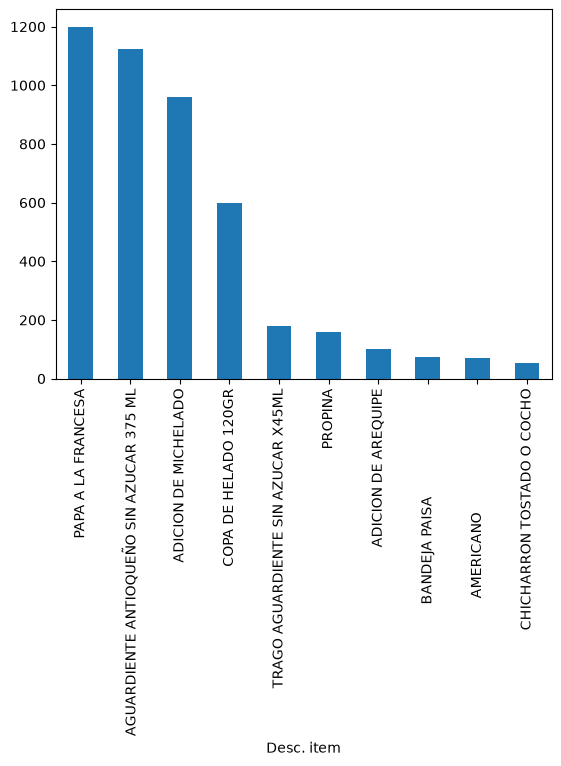

In [10]:
Productos_mas_vendidos.plot(kind="bar")

## Valor de facturas

In [11]:
Valor_facturas = df.groupby("Nro documento", sort=False)["Valor neto"].sum()

In [12]:
Valor_facturas

Nro documento
FE1-00019191     97500
FE1-00019192     95300
FE1-00019193    161100
FE1-00019194    197500
FE1-00019195     94200
                 ...  
FE1-00019362      8000
FE1-00019363     39600
FE1-00019364     20000
FE1-00019365    633200
FE1-00019366      6500
Name: Valor neto, Length: 176, dtype: int64

<Axes: xlabel='Nro documento'>

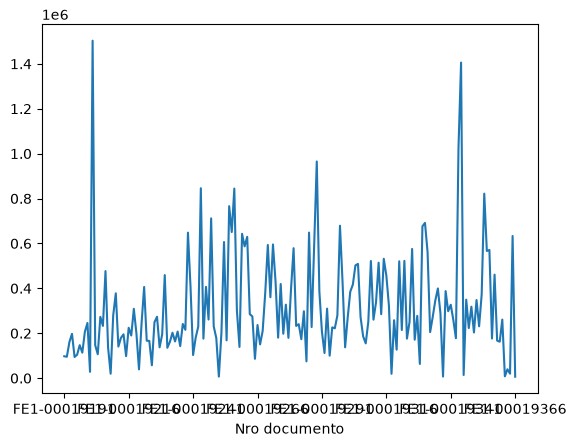

In [13]:
Valor_facturas.plot(kind="line")

In [14]:
promedio_valor_facturas = Valor_facturas.mean()
promedio_valor_facturas

np.float64(314974.26704545453)

In [15]:
mediana_valor_facturas = Valor_facturas.median()
mediana_valor_facturas

np.float64(247250.0)

In [16]:
desviacion_valor_facturas = Valor_facturas.std()
desviacion_valor_facturas

np.float64(236037.85147399496)

## Analisis valores netos

<Axes: >

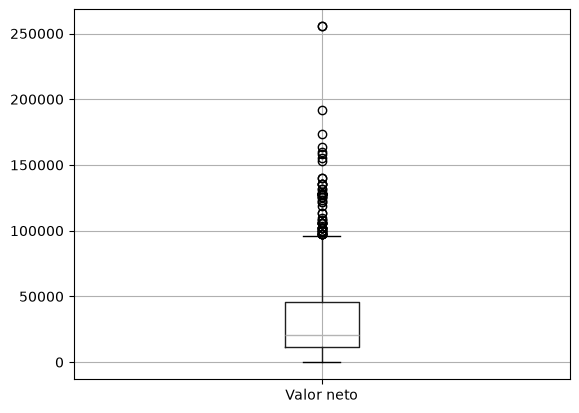

In [17]:
df.boxplot(column="Valor neto")

In [31]:
items_atipicos = df[["Desc. item", "Cantidad inv.", "Valor neto"]].sort_values("Valor neto", ascending=False).head(10)
items_atipicos

,Desc. item,Cantidad inv.,Valor neto
758,BANDEJA PAISA,4,255600
834,BANDEJA PAISA,4,255600
570,BANDEJA PAISA,3,191700
1628,PUNTA DE ANCA DE RES A LA PARRILLA,2,173800
1710,AJIACO MINI,4,163600
1029,SALMON A LA PLANCHA,2,159800
1077,CAZUELA PAISA,3,158700
86,CHICHARRON TOSTADO O COCHO,4,155600
1338,MARINILLO CON FRIJOLES,3,152700
761,SOBREBARRIGA DE RES A LA PARRILLA,2,139800


In [18]:
promedio = df["Valor neto"].mean()
mediana = df["Valor neto"].median()
desviacion = df["Valor neto"].std()

print("Promedio:", promedio)
print("Mediana:", mediana)
print("Desviación estándar:", desviacion)

Promedio: 31969.70645905421
Mediana: 20900.0
Desviación estándar: 28795.539044454385


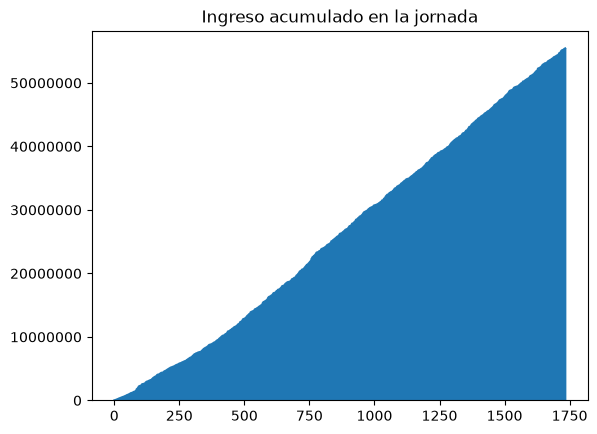

In [21]:
df["Valor neto"].cumsum().plot(kind="area")
plt.title("Ingreso acumulado en la jornada")
plt.ticklabel_format(style="plain", axis="y")

# LINK DEL VIDEO : https://youtu.be/0k2v-O6Hnf8?si=bQSu7FCj1Ecl3Nvv